## Consolidate Imports and Data Loading

### Subtask:
Set up the environment and load the dataset into a single, clean initial block.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/ADY201m/Student Insomnia and Educational Outcomes Dataset_version-2.csv')

print("Environment set up and dataset loaded successfully.")

Environment set up and dataset loaded successfully.


## Data Preprocessing

### Subtask:
Clean column names and apply numeric mapping for categorical variables in one integrated step.


In [ ]:
df.columns = df.columns.str.strip()

full_mapping = {
    'Timestamp': 'Record_Time',
    '1. What is your year of study?': 'Year',
    '2. What is your gender?': 'Gender',
    '3. How often do you have difficulty falling asleep at night?': 'Difficulty_Falling_Asleep',
    '4. On average, how many hours of sleep do you get on a typical day?': 'Sleep_Hours_Total',
    '5. How often do you wake up during the night and have trouble falling back asleep?': 'Waking_Up_During_Night',
    '6. How would you rate the overall quality of your sleep?': 'Overall_Sleep_Quality',
    '7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?': 'Sleep_Impact_on_Concentration',
    '8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?': 'Daytime_Fatigue',
    '9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?': 'Sleep_Impact_on_Attendance',
    '10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?': 'Sleep_Impact_on_Deadlines',
    '11. How often do you use electronic devices (e.g., phone, computer) before going to sleep?': 'Phone_Usage_Before_Sleep',
    '12. How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?': 'Caffeine_Intake',
    '13. How often do you engage in physical activity or exercise?': 'Exercise_Frequency',
    '14. How would you describe your stress levels related to academic workload?': 'Academic_Stress_Level',
    '15. How would you rate your overall academic performance (GPA or grades) in the past semester?': 'GPA_Rating'
}
df = df.rename(columns=full_mapping)

freq_map = {
    'Never': 0, 'Rarely': 1, 'Rarely (1-2 times a month)': 1, 'Rarely (1-2 times a week)': 1,
    'Sometimes': 2, 'Sometimes (1-2 times a week)': 2, 'Sometimes (3-4 times a week)': 2,
    'Often': 3, 'Often (3-4 times a week)': 3, 'Often (5-6 times a week)': 3,
    'Always': 4, 'Every day': 4, 'Every night': 4
}
sleep_duration_map = {'Less than 4 hours': 3.5, '4-5 hours': 4.5, '5-6 hours': 5.5, '6-7 hours': 6.5, '7-8 hours': 7.5, 'More than 8 hours': 8.5}
quality_map = {'Very poor': 1, 'Poor': 2, 'Average': 3, 'Good': 4, 'Very good': 5}
impact_map = {'No impact': 0, 'Minor impact': 1, 'Moderate impact': 2, 'Major impact': 3, 'Severe impact': 4}
stress_map = {'No stress': 0, 'Low stress': 1, 'High stress': 2, 'Extremely high stress': 3}
gpa_map = {'Poor': 1, 'Below Average': 2, 'Average': 3, 'Good': 4, 'Excellent': 5}
year_map = {'First year': 1, 'Second year': 2, 'Third year': 3, 'Graduate student': 4}
gender_map = {'Male': 0, 'Female': 1}

cols_freq = ['Difficulty_Falling_Asleep', 'Waking_Up_During_Night', 'Sleep_Impact_on_Concentration',
             'Daytime_Fatigue', 'Sleep_Impact_on_Attendance', 'Phone_Usage_Before_Sleep',
             'Caffeine_Intake', 'Exercise_Frequency']
for col in cols_freq: df[col] = df[col].map(freq_map)

df['Sleep_Hours_Total'] = df['Sleep_Hours_Total'].map(sleep_duration_map)
df['Overall_Sleep_Quality'] = df['Overall_Sleep_Quality'].map(quality_map)
df['Sleep_Impact_on_Deadlines'] = df['Sleep_Impact_on_Deadlines'].map(impact_map)
df['Academic_Stress_Level'] = df['Academic_Stress_Level'].map(stress_map)
df['GPA_Rating'] = df['GPA_Rating'].map(gpa_map)
df['Year'] = df['Year'].map(year_map)
df['Gender'] = df['Gender'].map(gender_map)

display(df.head())

,Record_Time,Year,Gender,Difficulty_Falling_Asleep,Sleep_Hours_Total,Waking_Up_During_Night,Overall_Sleep_Quality,Sleep_Impact_on_Concentration,Daytime_Fatigue,Sleep_Impact_on_Attendance,Sleep_Impact_on_Deadlines,Phone_Usage_Before_Sleep,Caffeine_Intake,Exercise_Frequency,Academic_Stress_Level,GPA_Rating
0,10/24/2024 16:51:15,4,0,3,7.5,3,4,2,3,3,2,3,1,2,2,3
1,10/24/2024 16:51:51,3,0,3,7.5,3,4,3,2,2,3,2,2,2,1,4
2,10/24/2024 16:52:21,1,1,2,7.5,2,4,3,3,2,3,3,3,3,2,2
3,10/24/2024 16:53:00,3,0,3,8.5,2,2,3,3,1,1,2,2,4,3,5
4,10/24/2024 16:53:25,4,0,3,7.5,3,5,4,2,2,2,2,2,3,1,3


## Integrated Data Cleaning and Feature Engineering

### Subtask:
Filter contradictory data rows and generate synthetic features for the analysis.


In [ ]:
# Feature Engineering
df['Academic_Burnout_Score'] = df['Sleep_Impact_on_Deadlines'] * df['Sleep_Impact_on_Concentration']
df['Sleep_Hygiene_Risk'] = df['Phone_Usage_Before_Sleep'] * df['Difficulty_Falling_Asleep']

df['Invalid_Data_Points'] = 0

# 1. High difficulty falling asleep but Very good quality
df.loc[(df['Sleep_Hygiene_Risk'] >= 16) & (df['Overall_Sleep_Quality'] >= 4), 'Invalid_Data_Points'] += 1

# 2. Very low sleep hours but No fatigue
df.loc[(df['Sleep_Hours_Total'] <= 3.5) & (df['Daytime_Fatigue'] <= 1), 'Invalid_Data_Points'] += 1

# 3. High Burnout but No stress
df.loc[(df['Academic_Burnout_Score'] >= 16) & (df['Academic_Stress_Level'] <= 1), 'Invalid_Data_Points'] += 1

# Filter to create df_clean and drop the tracker column
df_clean = df[df['Invalid_Data_Points'] == 0].copy()
df_clean = df_clean.drop(columns=['Invalid_Data_Points'])

print(f"Rows removed: {len(df) - len(df_clean)}")
print(f"Cleaned dataset size: {len(df_clean)}")
display(df_clean.head())

Rows removed: 121
Cleaned dataset size: 875


,Record_Time,Year,Gender,Difficulty_Falling_Asleep,Sleep_Hours_Total,Waking_Up_During_Night,Overall_Sleep_Quality,Sleep_Impact_on_Concentration,Daytime_Fatigue,Sleep_Impact_on_Attendance,Sleep_Impact_on_Deadlines,Phone_Usage_Before_Sleep,Caffeine_Intake,Exercise_Frequency,Academic_Stress_Level,GPA_Rating,Academic_Burnout_Score,Sleep_Hygiene_Risk
0,10/24/2024 16:51:15,4,0,3,7.5,3,4,2,3,3,2,3,1,2,2,3,4,9
1,10/24/2024 16:51:51,3,0,3,7.5,3,4,3,2,2,3,2,2,2,1,4,9,6
2,10/24/2024 16:52:21,1,1,2,7.5,2,4,3,3,2,3,3,3,3,2,2,9,6
3,10/24/2024 16:53:00,3,0,3,8.5,2,2,3,3,1,1,2,2,4,3,5,3,6
4,10/24/2024 16:53:25,4,0,3,7.5,3,5,4,2,2,2,2,2,3,1,3,8,6


## Exploratory Data Analysis (EDA)

### Subtask:
Generate a correlation matrix and distribution plots for the cleaned features in `df_clean` to identify key relationships.


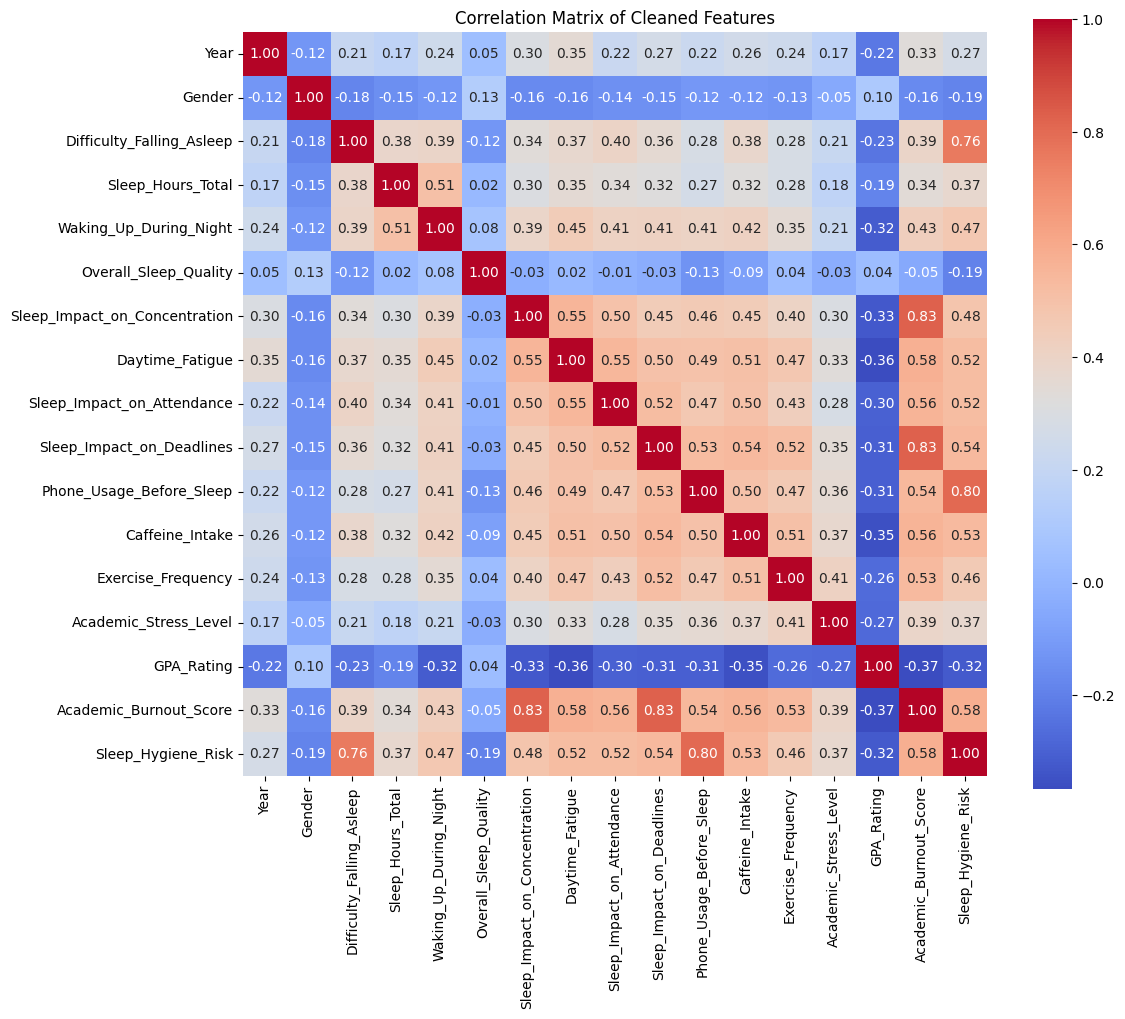

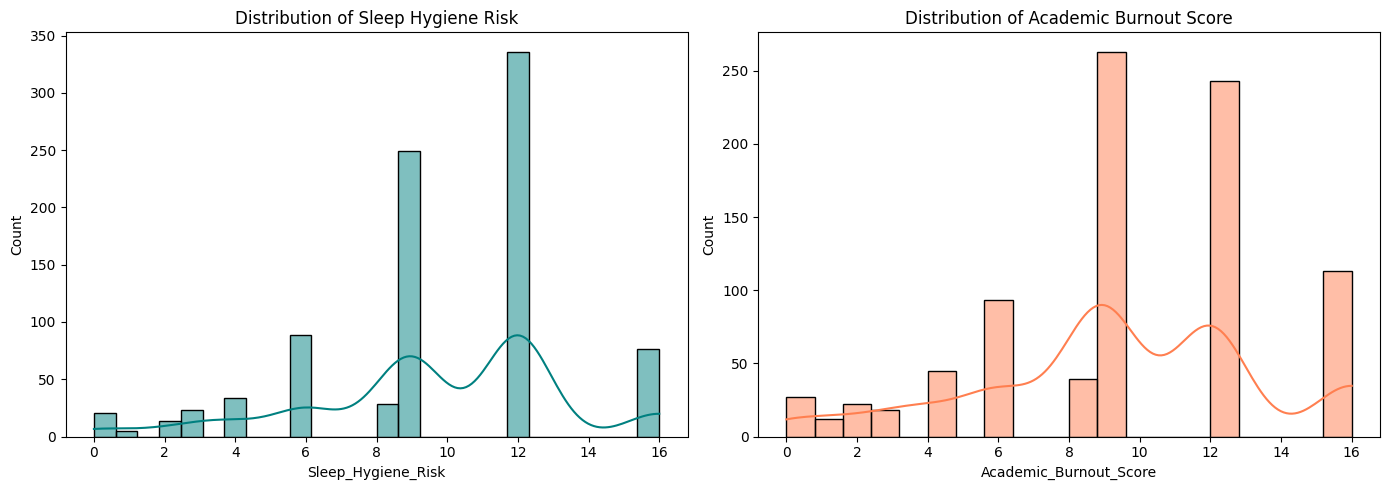

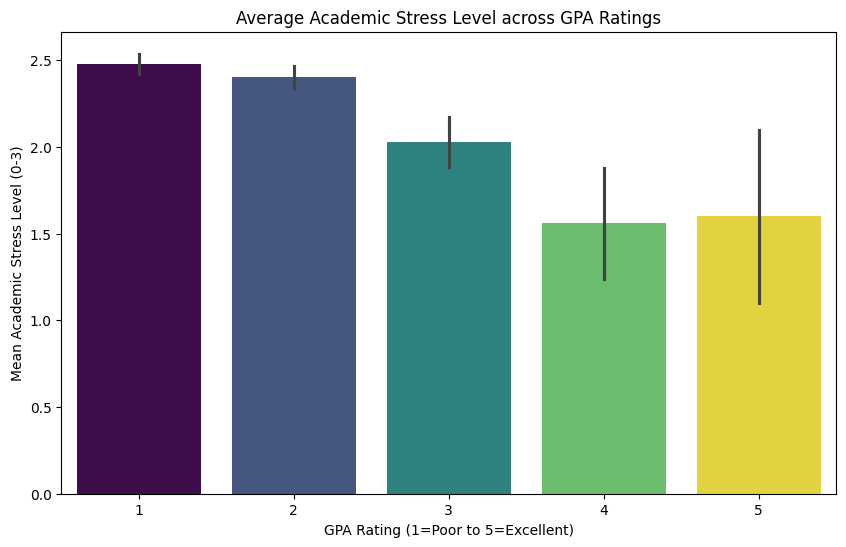

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate Correlation Matrix
corr_matrix = df_clean.corr(numeric_only=True)

# 2. Visualize Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Cleaned Features')
plt.show()

# 3. Distribution plots for engineered features
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_clean['Sleep_Hygiene_Risk'], kde=True, color='teal')
plt.title('Distribution of Sleep Hygiene Risk')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['Academic_Burnout_Score'], kde=True, color='coral')
plt.title('Distribution of Academic Burnout Score')

plt.tight_layout()
plt.show()

# 4. Relationship between Academic Stress and GPA Rating (Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(x='GPA_Rating', y='Academic_Stress_Level', data=df_clean, palette='viridis', hue='GPA_Rating', legend=False)
plt.title('Average Academic Stress Level across GPA Ratings')
plt.xlabel('GPA Rating (1=Poor to 5=Excellent)')
plt.ylabel('Mean Academic Stress Level (0-3)')
plt.show()

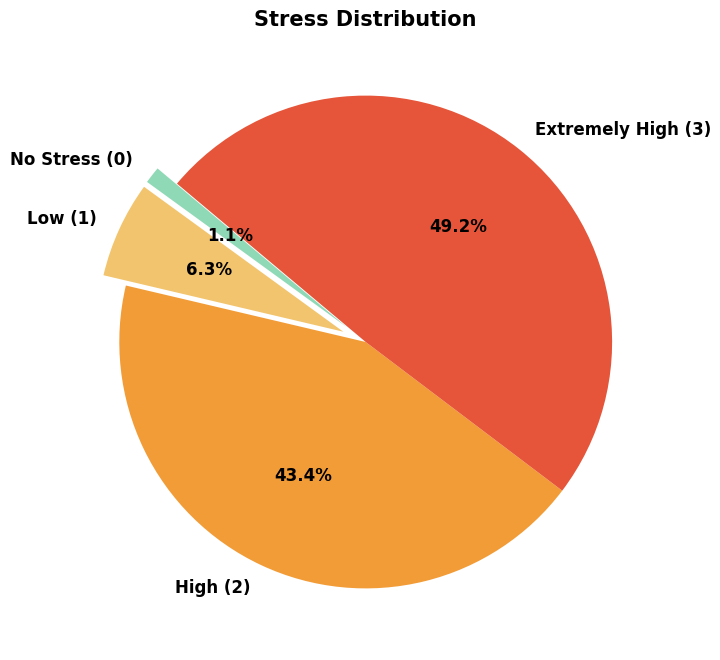

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả định DataFrame của cậu tên là df
plt.figure(figsize=(8, 8))

# Đếm số lượng từng mức stress và sắp xếp lại theo thứ tự 0, 1, 2, 3
stress_counts = df['Academic_Stress_Level'].value_counts().sort_index()
labels = ['No Stress (0)', 'Low (1)', 'High (2)', 'Extremely High (3)']

# Chọn mã màu nổi bật, nhấn mạnh vào mức 2 và 3
colors = ['#8fd9b6', '#f2c46d', '#f29c38', '#e65539']

# Vẽ biểu đồ tròn với phần trăm
plt.pie(stress_counts, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold'},
        explode=(0.1, 0.1, 0, 0)) # Tách nhẹ 2 nhóm nhỏ ra cho dễ nhìn

plt.title('Stress Distribution', fontsize=15, fontweight='bold')

plt.savefig('stress_pie_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


/tmp/ipykernel_654/267752996.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Academic_Stress_Level', y='Sleep_Hygiene_Risk', data=df,


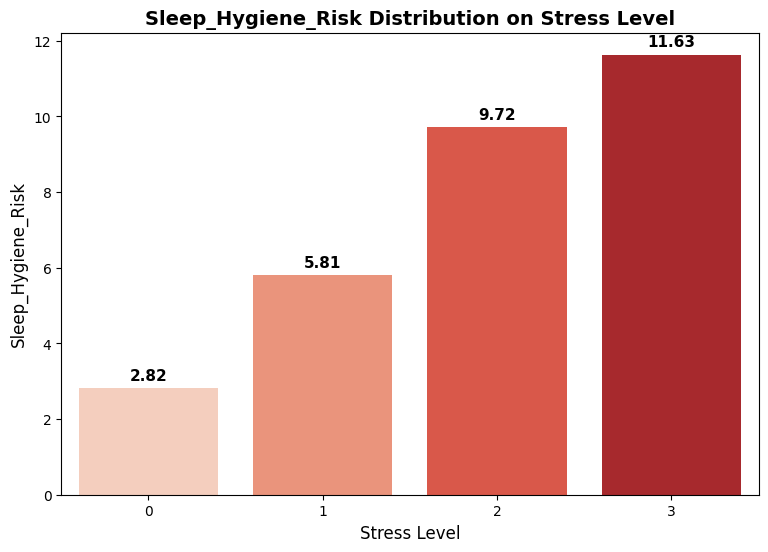

In [ ]:
plt.figure(figsize=(9, 6))

# sns.barplot tự động tính giá trị TRUNG BÌNH (mean) của cột y cho từng nhóm x
ax = sns.barplot(x='Academic_Stress_Level', y='Sleep_Hygiene_Risk', data=df,
                 palette='Reds', errorbar=None) # errorbar=None để bỏ cái râu đen đi cho gọn mắt

plt.title('Sleep_Hygiene_Risk Distribution on Stress Level', fontsize=14, fontweight='bold')
plt.xlabel('Stress Level', fontsize=12)
plt.ylabel('Sleep_Hygiene_Risk', fontsize=12)

# Thêm con số cụ thể lên đầu mỗi cột
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.savefig('sleep_hygiene_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

/tmp/ipykernel_654/1213693848.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='GPA_Rating', y='Academic_Stress_Level', data=df,


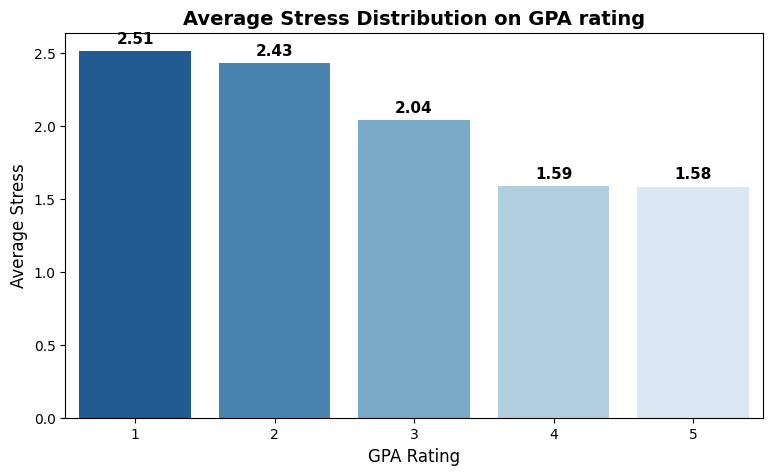

In [ ]:
plt.figure(figsize=(9, 5))

# Vẽ biểu đồ cột xem mức stress trung bình theo từng mức GPA
ax = sns.barplot(x='GPA_Rating', y='Academic_Stress_Level', data=df,
                 palette='Blues_r', errorbar=None)

plt.title('Average Stress Distribution on GPA rating', fontsize=14, fontweight='bold')
plt.xlabel('GPA Rating', fontsize=12)
plt.ylabel('Average Stress', fontsize=12)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.savefig('gpa_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Model Training and Evaluation

### Subtask:
Compare a baseline OLS regression with an optimized Random Forest Regressor using the cleaned dataset.


In [ ]:
import statsmodels.api as sm

print("="*60)
print("KẾT QUẢ PHÂN TÍCH NHÂN QUẢ BẰNG OLS (TRẢ LỜI RQ1)")
print("="*60)

# ---------------------------------------------------------
# MÔ HÌNH 1: TÁC ĐỘNG LÊN MỨC ĐỘ STRESS
# ---------------------------------------------------------
print("\n[MÔ HÌNH 1] CÁC YẾU TỐ TÁC ĐỘNG ĐẾN ACADEMIC STRESS LEVEL")
features_stress = ['Academic_Burnout_Score', 'Sleep_Hygiene_Risk', 'Overall_Sleep_Quality', 'Exercise_Frequency']
X_stress = sm.add_constant(df_clean[features_stress])
y_stress = df_clean['Academic_Stress_Level']

ols_stress = sm.OLS(y_stress, X_stress).fit()

# In ra các hệ số có ý nghĩa (p < 0.05)
print("\n--- Hệ số tác động (Chỉ lấy các biến có ý nghĩa thống kê p < 0.05) ---")
pvalues_stress = ols_stress.pvalues
coefs_stress = ols_stress.params
for index in coefs_stress.index:
    if index != 'const' and pvalues_stress[index] < 0.05:
        print(f" - {index}: {coefs_stress[index]:.4f} (p-value: {pvalues_stress[index]:.4f})")

# ---------------------------------------------------------
# MÔ HÌNH 2: TÁC ĐỘNG LÊN KẾT QUẢ HỌC TẬP (GPA)
# ---------------------------------------------------------
print("\n\n[MÔ HÌNH 2] CÁC YẾU TỐ TÁC ĐỘNG ĐẾN KẾT QUẢ HỌC TẬP (GPA RATING)")
# Dùng giấc ngủ, sự kiệt sức và cả mức stress để xem nó kéo tụt GPA ra sao
features_gpa = ['Sleep_Hygiene_Risk', 'Overall_Sleep_Quality', 'Academic_Burnout_Score', 'Academic_Stress_Level']
X_gpa = sm.add_constant(df_clean[features_gpa])
y_gpa = df_clean['GPA_Rating']

ols_gpa = sm.OLS(y_gpa, X_gpa).fit()

print("\n--- Hệ số tác động (Chỉ lấy các biến có ý nghĩa thống kê p < 0.05) ---")
pvalues_gpa = ols_gpa.pvalues
coefs_gpa = ols_gpa.params
for index in coefs_gpa.index:
    if index != 'const' and pvalues_gpa[index] < 0.05:
        print(f" - {index}: {coefs_gpa[index]:.4f} (p-value: {pvalues_gpa[index]:.4f})")

print("\n" + "="*60)

KẾT QUẢ PHÂN TÍCH NHÂN QUẢ BẰNG OLS (TRẢ LỜI RQ1)

[MÔ HÌNH 1] CÁC YẾU TỐ TÁC ĐỘNG ĐẾN ACADEMIC STRESS LEVEL

--- Hệ số tác động (Chỉ lấy các biến có ý nghĩa thống kê p < 0.05) ---
 - Academic_Burnout_Score: 0.0254 (p-value: 0.0001)
 - Sleep_Hygiene_Risk: 0.0299 (p-value: 0.0000)
 - Exercise_Frequency: 0.2051 (p-value: 0.0000)


[MÔ HÌNH 2] CÁC YẾU TỐ TÁC ĐỘNG ĐẾN KẾT QUẢ HỌC TẬP (GPA RATING)

--- Hệ số tác động (Chỉ lấy các biến có ý nghĩa thống kê p < 0.05) ---
 - Sleep_Hygiene_Risk: -0.0310 (p-value: 0.0006)
 - Academic_Burnout_Score: -0.0482 (p-value: 0.0000)
 - Academic_Stress_Level: -0.1644 (p-value: 0.0001)



In [ ]:
# 1. Define feature matrix X and target vector y
features_model = ['Academic_Burnout_Score', 'Sleep_Hygiene_Risk', 'Overall_Sleep_Quality', 'Exercise_Frequency', 'GPA_Rating', 'Sleep_Hours_Total' ]
X = df_clean[features_model]
y = df_clean['Academic_Stress_Level']
1111
# 2. Split the data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Baseline OLS model
X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)
ols_model = sm.OLS(y_train, X_train_ols).fit()
y_pred_ols = ols_model.predict(X_test_ols)

# 4. Optimized Random Forest Regressor
rf_optimized = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
rf_optimized.fit(X_train, y_train)
y_pred_rf = rf_optimized.predict(X_test)

# 5. Evaluate and print performance
print("--- OLS Baseline Performance (Test Set) ---")
print(f"R-squared: {r2_score(y_test, y_pred_ols):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_ols):.3f}")

print("\n--- Optimized Random Forest Performance (Test Set) ---")
print(f"R-squared: {r2_score(y_test, y_pred_rf):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.3f}")

--- OLS Baseline Performance (Test Set) ---
R-squared: 0.246
MAE: 0.528

--- Optimized Random Forest Performance (Test Set) ---
R-squared: 0.241
MAE: 0.531


## Final Visualization and Export

### Subtask:
Generate the final performance comparison visualizations and export the processed dataset.


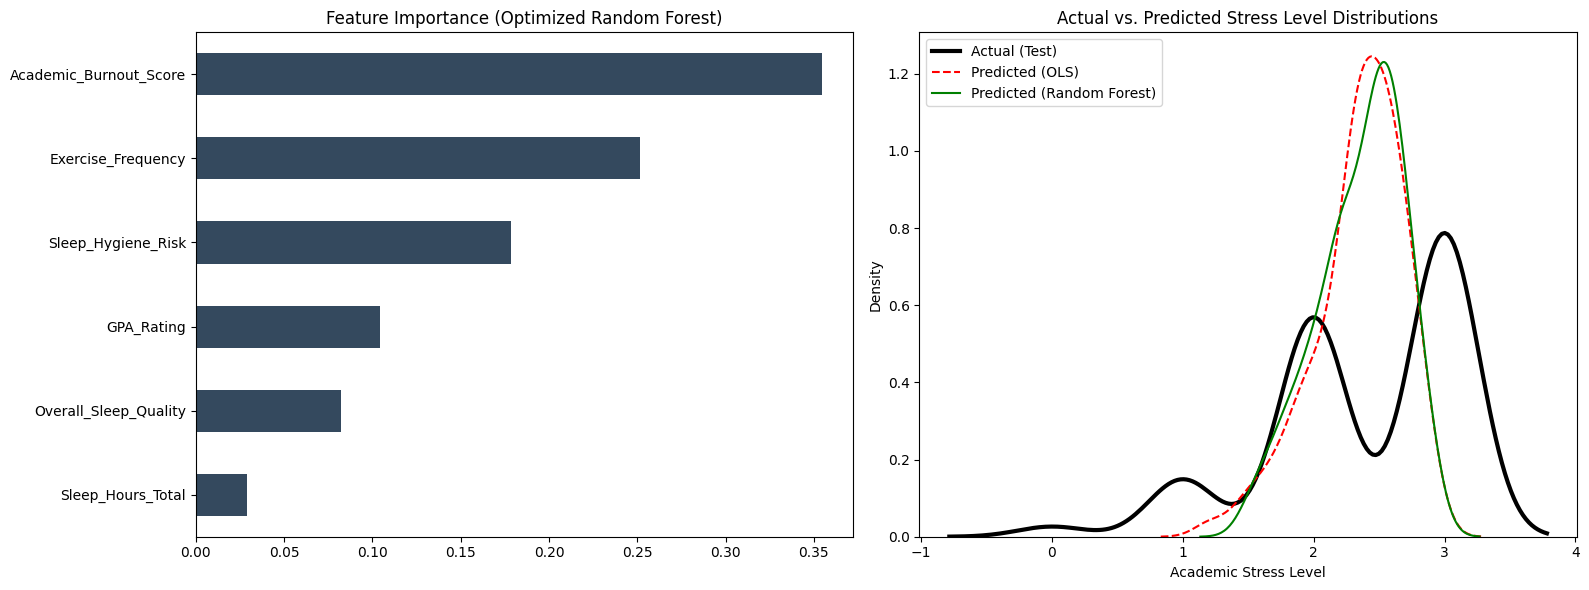

Dataset exported successfully to 'Student_Mental_Health_Final.csv'.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create a figure with two subplots
plt.figure(figsize=(16, 6))

# 2. Subplot 1: Feature Importance
plt.subplot(1, 2, 1)
importances = rf_optimized.feature_importances_
feat_importances = pd.Series(importances, index=features_model).sort_values()
feat_importances.plot(kind='barh', color='#34495e')
plt.title('Feature Importance (Optimized Random Forest)')

# 3. Subplot 2: KDE Plot Comparison
plt.subplot(1, 2, 2)
sns.kdeplot(y_test, label='Actual (Test)', color='black', linewidth=3)
sns.kdeplot(y_pred_ols, label='Predicted (OLS)', color='red', linestyle='--')
sns.kdeplot(y_pred_rf, label='Predicted (Random Forest)', color='green')
plt.title('Actual vs. Predicted Stress Level Distributions')
plt.xlabel('Academic Stress Level')
plt.legend()

# 4. Apply tight_layout and show plots
plt.tight_layout()
plt.show()

# 5. Predict stress levels for the entire cleaned dataset
df_clean['Stress_Predicted'] = rf_optimized.predict(df_clean[features_model])

# 6. Export the cleaned DataFrame to CSV
df_clean.to_csv('Student_Mental_Health_Final.csv', index=False)
print("Dataset exported successfully to 'Student_Mental_Health_Final.csv'.")